## Question 1

### What is Boosting in Machine Learning? Explain how it improves weak learners.

**Answer**:
Boosting is an ensemble learning technique that combines multiple weak learners (usually decision trees) sequentially to create a strong predictive model. Each new model focuses more on the mistakes made by the previous models. By repeatedly correcting errors and assigning higher importance to misclassified samples, boosting reduces bias and improves overall model accuracy.

## Question 2

### What is the difference between AdaBoost and Gradient Boosting in terms of how models are trained?

**Answer**:
AdaBoost trains models sequentially and increases the weights of misclassified observations so that the next learner focuses on them. Gradient Boosting trains models sequentially by fitting each new model to the residual errors (gradients) of the previous model. AdaBoost uses sample weighting, whereas Gradient Boosting uses gradient-based optimization.

## Question 3

### How does regularization help in XGBoost?

**Answer**:
Regularization helps prevent overfitting by penalizing overly complex models. XGBoost uses both L1 (Lasso) and L2 (Ridge) regularization on leaf weights, which controls model complexity, improves generalization, and produces more robust predictions on unseen data.

## Question 4

### Why is CatBoost considered efficient for handling categorical data?

**Answer**:
CatBoost can process categorical features directly without requiring extensive preprocessing such as one-hot encoding. It uses target-based encoding techniques and ordered boosting to reduce target leakage, improve accuracy, and handle high-cardinality categorical variables efficiently.

## Question 5

### What are some real-world applications where boosting techniques are preferred over bagging methods?

**Answer**:
Boosting techniques are commonly used in:
1. Credit risk and loan default prediction
2. Fraud detection
3. Customer churn prediction
4. Medical diagnosis
5. Recommendation systems
6. Search ranking systems
7. Insurance claim prediction

Boosting is preferred when maximum predictive accuracy is required.

# Question 6
### Train an AdaBoost Classifier on the Breast Cancer dataset and print accuracy.

```python
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = AdaBoostClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
```


# Question 7

### Train a Gradient Boosting Regressor on the California Housing dataset and evaluate using R² score.

In [2]:

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

data = fetch_california_housing()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.7756446042829697


# Question 8
### Train an XGBoost Classifier and tune learning rate using GridSearchCV.




In [8]:
import sys

!{sys.executable} -m pip install xgboost

from xgboost import XGBClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score

X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

params = {'learning_rate':[0.01,0.05,0.1,0.2]}

grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss'),
    params,
    cv=3,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

y_pred = grid.best_estimator_.predict(X_test)

print("Best Parameters:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))


Best Parameters: {'learning_rate': 0.1}
Accuracy: 0.956140350877193


# Question 9
### Train a CatBoost Classifier and plot the confusion matrix.



ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\Users\\Asus\\anaconda3\\envs\\myenv\\Lib\\site-packages\\xgboost\\lib\\xgboost.dll'
Consider using the `--user` option or check the permissions.



  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 184.3 kB/s eta 0:09:0

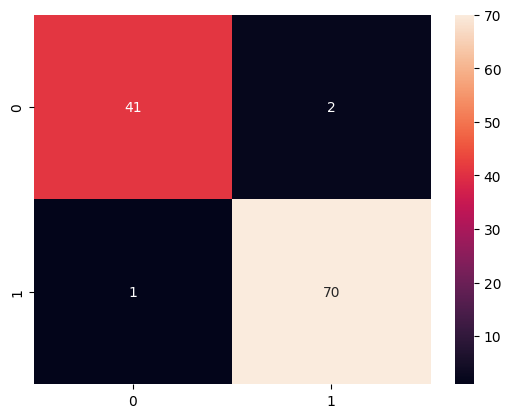

In [12]:
import sys

!{sys.executable} -m pip install catboost

from catboost import CatBoostClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = CatBoostClassifier(verbose=0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()


# Question 10
Loan Default Prediction Pipeline

### Data Preprocessing
- Handle missing values using median/mode imputation.
- Encode categorical variables.
- Split data into training and testing sets.

### Model Choice
- CatBoost is preferred because it handles categorical features and missing values efficiently.

### Hyperparameter Tuning
- Use GridSearchCV or RandomizedSearchCV.
- Tune learning rate, depth, iterations, and regularization parameters.

### Evaluation Metrics
- ROC-AUC
- Precision
- Recall
- F1-Score
- Confusion Matrix

### Business Benefits
- Reduced loan defaults.
- Better credit risk assessment.
- Improved profitability.
- Faster loan approval decisions.
